<a href="https://colab.research.google.com/github/4551kiet-999/GOOGLE-PAGE-RANK-MINI/blob/main/Front%20end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 Google PageRank Mini (B2)

### B.Tech Mathematics Mini Project

MATHEMATICAL MODEL

PageRank uses the following mathematical model:

PR(k+1) = G × PR(k)

where:

G = dM + (1-d)/N

At convergence:

PR = G × PR

Therefore:

G × PR = 1 × PR

Hence the PageRank vector is the eigenvector
corresponding to eigenvalue λ = 1.

WEB LINK STRUCTURE
A → B, C
B → C
C → A, D
D → C, E
E → A

TRANSITION MATRIX M


,A,B,C,D,E
A,0.000,0.000,0.500,0.000,1.000
B,0.500,0.000,0.000,0.000,0.000
C,0.500,1.000,0.000,0.500,0.000
D,0.000,0.000,0.500,0.000,0.000
E,0.000,0.000,0.000,0.500,0.000


GOOGLE MATRIX G


,A,B,C,D,E
A,0.030000,0.030000,0.455000,0.030000,0.880000
B,0.455000,0.030000,0.030000,0.030000,0.030000
C,0.455000,0.880000,0.030000,0.455000,0.030000
D,0.030000,0.030000,0.455000,0.030000,0.030000
E,0.030000,0.030000,0.030000,0.455000,0.030000


POWER ITERATION
Converged after 41 iterations.


,Iteration,A,B,C,D,E
32,32,0.257445,0.139414,0.330333,0.170391,0.102416
33,33,0.257445,0.139414,0.330333,0.170391,0.102416
34,34,0.257445,0.139414,0.330333,0.170391,0.102416
35,35,0.257445,0.139414,0.330333,0.170391,0.102416
36,36,0.257445,0.139414,0.330333,0.170391,0.102416
37,37,0.257445,0.139414,0.330333,0.170391,0.102416
38,38,0.257445,0.139414,0.330333,0.170391,0.102416
39,39,0.257445,0.139414,0.330333,0.170391,0.102416
40,40,0.257445,0.139414,0.330333,0.170391,0.102416
41,41,0.257445,0.139414,0.330333,0.170391,0.102416


EIGENVALUE VERIFICATION
Eigenvalue closest to 1: (1.0000000000000016+0j)

Eigenvector for λ = 1:
A = 0.257445
B = 0.139414
C = 0.330333
D = 0.170391
E = 0.102416

PageRank from Power Iteration:
A = 0.257445
B = 0.139414
C = 0.330333
D = 0.170391
E = 0.102416

FINAL RESULT
Most Important Page : C
PageRank Score      : 0.330333
Percentage          : 33.03%

FINAL PAGERANK RANKING


,Rank,Page,PageRank,Percentage
0,1,C,0.330333,33.03%
1,2,A,0.257445,25.74%
2,3,D,0.170391,17.04%
3,4,B,0.139414,13.94%
4,5,E,0.102416,10.24%


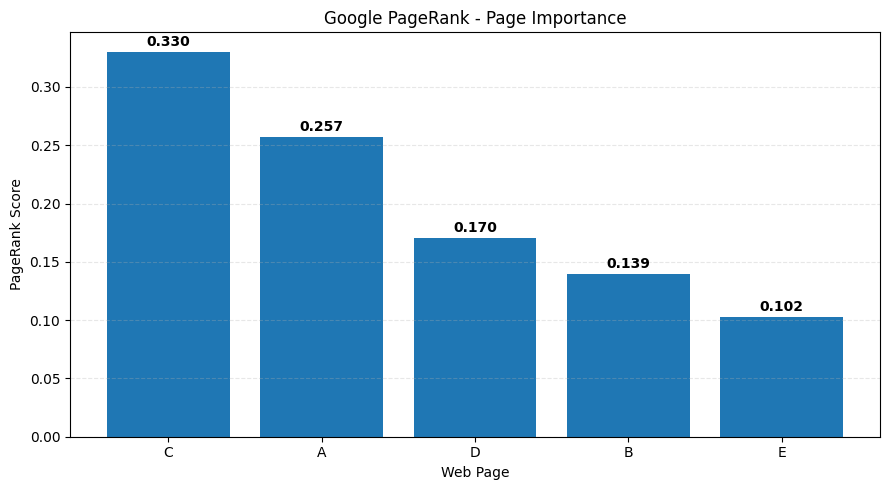

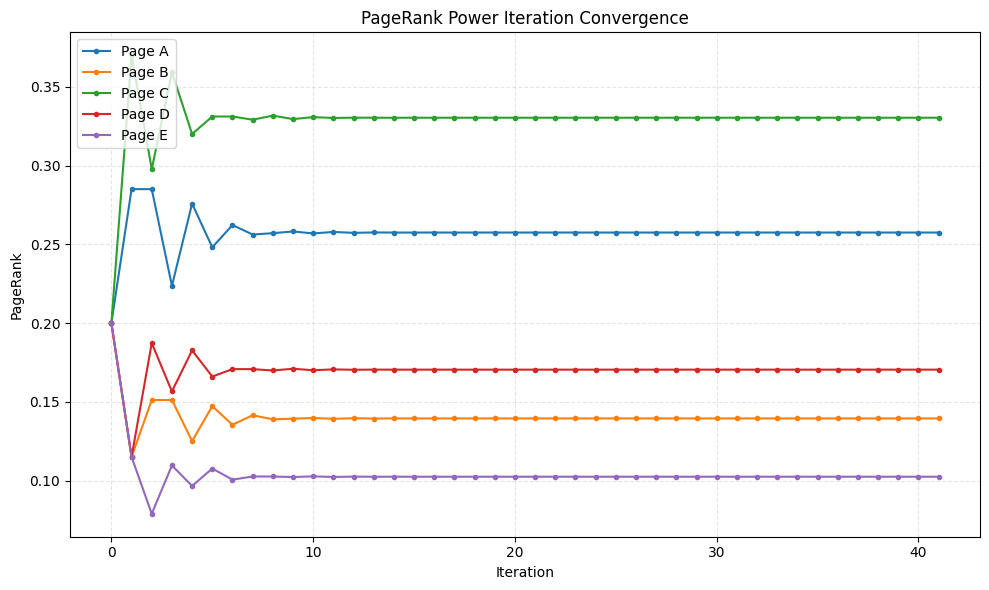

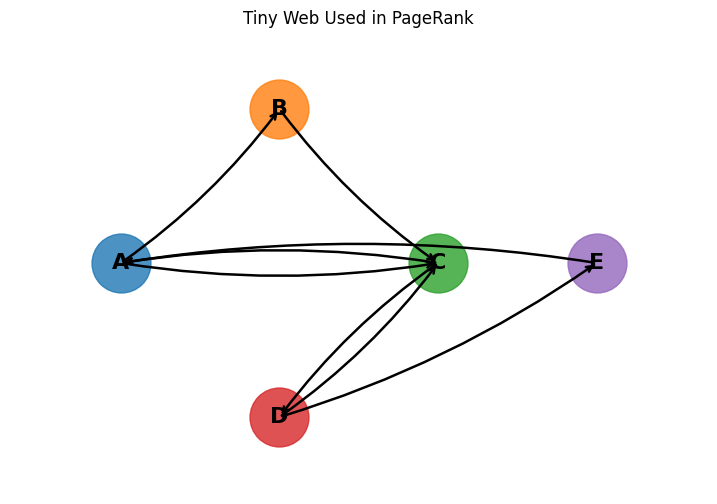


## ✅ Project Conclusion

The PageRank algorithm was successfully implemented
using **power iteration**.

- Number of pages: **5**
- Damping factor: **0.85**
- Iterations: **41**
- Eigenvalue: approximately **1**
- Most important page: **C**
- PageRank score: **0.330333**

### Mathematical Conclusion

The PageRank vector is the **steady-state eigenvector**
of the Google matrix corresponding to the eigenvalue:

$$
\boxed{\lambda = 1}
$$

Therefore, **Page C has the highest
importance in the given web network.**



GOOGLE PAGERANK MINI PROJECT COMPLETED


In [3]:

# ============================================================
# GOOGLE PAGERANK MINI (B2)
# B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
import ipywidgets as widgets


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# Number of web pages
PAGE_NAMES = ["A", "B", "C", "D", "E"]

# Damping factor used in Google's PageRank model
DAMPING = 0.85

# Accuracy settings
TOLERANCE = 1e-10
MAX_ITERATIONS = 100

# Benchmark web structure
#
# A -> B, C
# B -> C
# C -> A, D
# D -> C, E
# E -> A
#
LINKS = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A", "D"],
    "D": ["C", "E"],
    "E": ["A"]
}


# ============================================================
# 2. BUILD TRANSITION MATRIX
# ============================================================

def build_transition_matrix(page_names, links):

    n = len(page_names)

    # M[i,j] = probability of moving
    # from page j to page i
    M = np.zeros((n, n))

    index = {
        page: i
        for i, page in enumerate(page_names)
    }

    for source in page_names:

        source_index = index[source]
        targets = links[source]

        # If a page has no outgoing links,
        # distribute probability equally.
        if len(targets) == 0:

            M[:, source_index] = 1 / n

        else:

            probability = 1 / len(targets)

            for target in targets:

                target_index = index[target]

                M[target_index, source_index] = probability

    return M


M = build_transition_matrix(
    PAGE_NAMES,
    LINKS
)


# ============================================================
# 3. GOOGLE MATRIX
# ============================================================

N = len(PAGE_NAMES)

# Google PageRank matrix:
#
# G = dM + (1-d)/N
#
# This prevents pages from getting zero probability.

G = (
    DAMPING * M
    + (1 - DAMPING) * np.ones((N, N)) / N
)


# ============================================================
# 4. POWER ITERATION
# ============================================================

def pagerank_power_iteration(
    M,
    damping=0.85,
    tolerance=1e-10,
    max_iterations=100
):

    n = M.shape[0]

    # Google matrix
    G = (
        damping * M
        + (1 - damping)
        * np.ones((n, n)) / n
    )

    # Initial PageRank:
    # all pages have equal importance
    rank = np.ones(n) / n

    history = [rank.copy()]

    for iteration in range(
        1,
        max_iterations + 1
    ):

        # Power iteration:
        #
        # PR(k+1) = G PR(k)
        new_rank = G @ rank

        # Convergence error
        error = np.linalg.norm(
            new_rank - rank,
            ord=1
        )

        history.append(
            new_rank.copy()
        )

        rank = new_rank

        if error < tolerance:

            return (
                rank,
                iteration,
                np.array(history),
                G
            )

    return (
        rank,
        max_iterations,
        np.array(history),
        G
    )


# Run PageRank
page_rank, iterations, history, G = (
    pagerank_power_iteration(
        M,
        DAMPING,
        TOLERANCE,
        MAX_ITERATIONS
    )
)


# ============================================================
# 5. EIGENVALUE = 1 VERIFICATION
# ============================================================

eigenvalues, eigenvectors = np.linalg.eig(G)

# Find eigenvalue closest to 1
index_1 = np.argmin(
    np.abs(eigenvalues - 1)
)

eigenvalue_1 = eigenvalues[index_1]

eigenvector_1 = np.real(
    eigenvectors[:, index_1]
)

# Normalize eigenvector
eigenvector_1 = (
    eigenvector_1
    / np.sum(eigenvector_1)
)


# ============================================================
# 6. RESULT TABLE
# ============================================================

results = pd.DataFrame({

    "Page": PAGE_NAMES,

    "PageRank": page_rank

})

results["Percentage"] = (
    results["PageRank"] * 100
)

results = results.sort_values(
    "PageRank",
    ascending=False
).reset_index(drop=True)

results["Rank"] = np.arange(
    1,
    N + 1
)

results = results[
    [
        "Rank",
        "Page",
        "PageRank",
        "Percentage"
    ]
]


# ============================================================
# 7. DISPLAY PROJECT
# ============================================================

display(
    Markdown(
        "# 🌐 Google PageRank Mini (B2)"
    )
)

display(
    Markdown(
        "### B.Tech Mathematics Mini Project"
    )
)

print("=" * 60)
print("MATHEMATICAL MODEL")
print("=" * 60)

print("""
PageRank uses the following mathematical model:

PR(k+1) = G × PR(k)

where:

G = dM + (1-d)/N

At convergence:

PR = G × PR

Therefore:

G × PR = 1 × PR

Hence the PageRank vector is the eigenvector
corresponding to eigenvalue λ = 1.
""")


# ============================================================
# 8. LINK STRUCTURE
# ============================================================

print("=" * 60)
print("WEB LINK STRUCTURE")
print("=" * 60)

for page, targets in LINKS.items():

    if targets:

        print(
            f"{page} → {', '.join(targets)}"
        )

    else:

        print(
            f"{page} → No outgoing links"
        )


# ============================================================
# 9. TRANSITION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("TRANSITION MATRIX M")
print("=" * 60)

display(
    pd.DataFrame(
        M,
        index=PAGE_NAMES,
        columns=PAGE_NAMES
    ).style.format("{:.3f}")
)


# ============================================================
# 10. GOOGLE MATRIX
# ============================================================

print("=" * 60)
print("GOOGLE MATRIX G")
print("=" * 60)

display(
    pd.DataFrame(
        G,
        index=PAGE_NAMES,
        columns=PAGE_NAMES
    ).style.format("{:.6f}")
)


# ============================================================
# 11. POWER ITERATION RESULTS
# ============================================================

print("=" * 60)
print("POWER ITERATION")
print("=" * 60)

print(
    f"Converged after {iterations} iterations."
)

iteration_table = pd.DataFrame(
    history,
    columns=PAGE_NAMES
)

iteration_table.insert(
    0,
    "Iteration",
    np.arange(len(history))
)

display(
    iteration_table.tail(10).style.format(
        {
            "A": "{:.6f}",
            "B": "{:.6f}",
            "C": "{:.6f}",
            "D": "{:.6f}",
            "E": "{:.6f}"
        }
    )
)


# ============================================================
# 12. EIGENVALUE CHECK
# ============================================================

print("=" * 60)
print("EIGENVALUE VERIFICATION")
print("=" * 60)

print(
    "Eigenvalue closest to 1:",
    eigenvalue_1
)

print("\nEigenvector for λ = 1:")

for page, value in zip(
    PAGE_NAMES,
    eigenvector_1
):

    print(
        f"{page} = {value:.6f}"
    )

print("\nPageRank from Power Iteration:")

for page, value in zip(
    PAGE_NAMES,
    page_rank
):

    print(
        f"{page} = {value:.6f}"
    )


# ============================================================
# 13. MOST IMPORTANT PAGE
# ============================================================

most_important = results.iloc[0]

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print(
    f"Most Important Page : {most_important['Page']}"
)

print(
    f"PageRank Score      : "
    f"{most_important['PageRank']:.6f}"
)

print(
    f"Percentage          : "
    f"{most_important['Percentage']:.2f}%"
)


# ============================================================
# 14. FINAL RANKING TABLE
# ============================================================

print("\n" + "=" * 60)
print("FINAL PAGERANK RANKING")
print("=" * 60)

display(
    results.style.format(
        {
            "PageRank": "{:.6f}",
            "Percentage": "{:.2f}%"
        }
    )
)


# ============================================================
# 15. BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results["Page"],
    results["PageRank"]
)

plt.title(
    "Google PageRank - Page Importance"
)

plt.xlabel("Web Page")

plt.ylabel("PageRank Score")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for i, value in enumerate(
    results["PageRank"]
):

    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 16. POWER ITERATION CONVERGENCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

for i, page in enumerate(
    PAGE_NAMES
):

    plt.plot(
        history[:, i],
        marker="o",
        markersize=3,
        label=f"Page {page}"
    )

plt.title(
    "PageRank Power Iteration Convergence"
)

plt.xlabel("Iteration")

plt.ylabel("PageRank")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 17. PAGE LINK NETWORK
# ============================================================

plt.figure(figsize=(9, 6))

positions = {
    "A": (0, 1),
    "B": (1, 2),
    "C": (2, 1),
    "D": (1, 0),
    "E": (3, 1)
}

# Draw pages
for page, (x, y) in positions.items():

    plt.scatter(
        x,
        y,
        s=1800,
        alpha=0.8
    )

    plt.text(
        x,
        y,
        page,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold"
    )


# Draw links
for source, targets in LINKS.items():

    x1, y1 = positions[source]

    for target in targets:

        x2, y2 = positions[target]

        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.8,
                connectionstyle="arc3,rad=0.08"
            )
        )

plt.title(
    "Tiny Web Used in PageRank"
)

plt.xlim(-0.7, 3.7)

plt.ylim(-0.5, 2.5)

plt.axis("off")

plt.show()


# ============================================================
# 18. PROJECT CONCLUSION
# ============================================================

display(
    Markdown(
        f"""
## ✅ Project Conclusion

The PageRank algorithm was successfully implemented
using **power iteration**.

- Number of pages: **{N}**
- Damping factor: **{DAMPING}**
- Iterations: **{iterations}**
- Eigenvalue: approximately **1**
- Most important page: **{most_important['Page']}**
- PageRank score: **{most_important['PageRank']:.6f}**

### Mathematical Conclusion

The PageRank vector is the **steady-state eigenvector**
of the Google matrix corresponding to the eigenvalue:

$$
\\boxed{{\\lambda = 1}}
$$

Therefore, **Page {most_important['Page']} has the highest
importance in the given web network.**
"""
    )
)

print("\n" + "=" * 60)
print("GOOGLE PAGERANK MINI PROJECT COMPLETED")
print("=" * 60)